In [16]:
S_l21=[0.8166,0.3862,0.2011,0.2015,0.2015]
S_l22=[0.8169,0.3834,0.1980,0.1975,0.1975]
len_cell_store1=[16,64,256,457,688]
len_cell_store2=[16,64,256,865,1426]

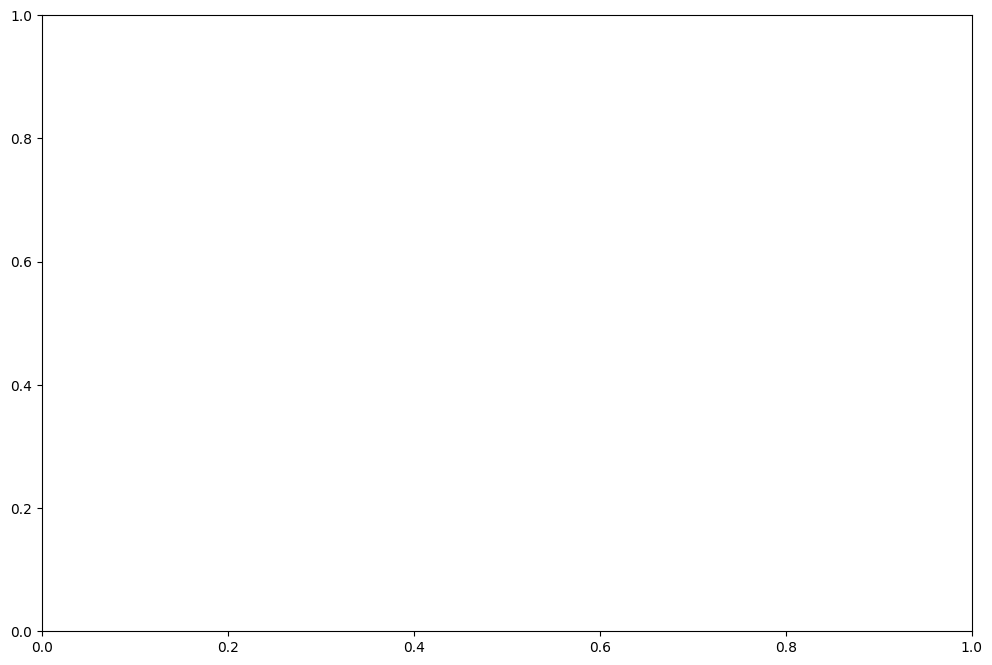

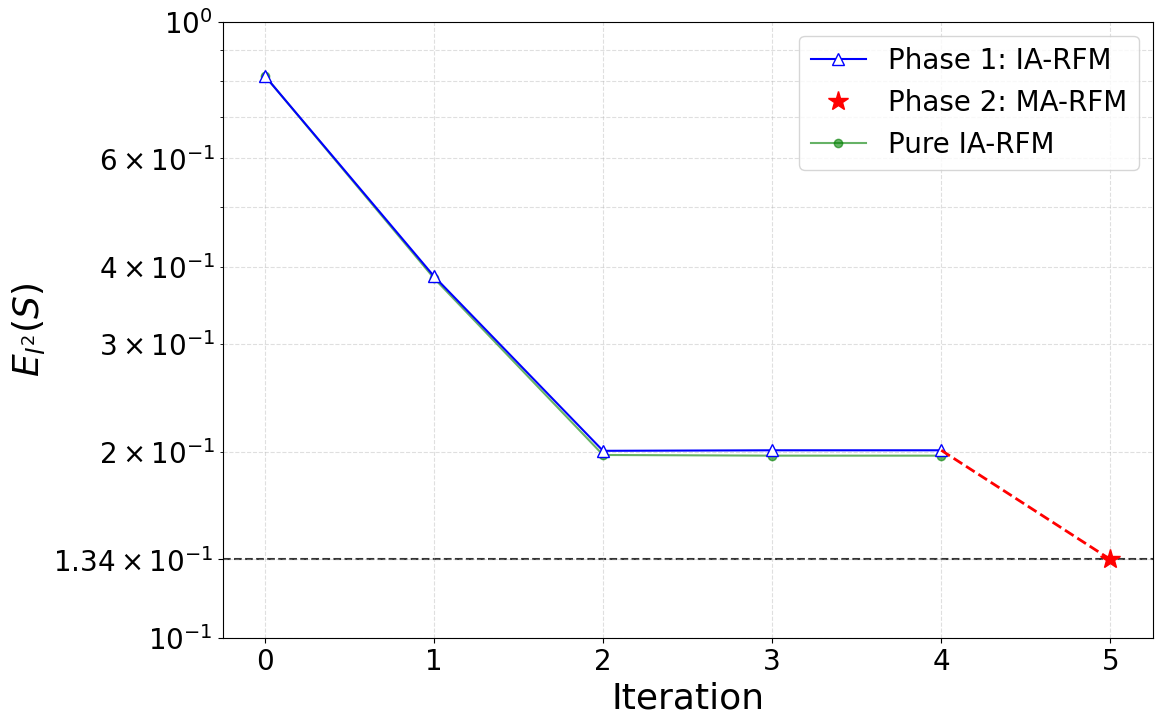

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)



plt.figure(figsize=(12, 8))

S_MARFM = S_l21.copy()
S_MARFM.append(0.134)
# 假设数据
iterations = range(0, len(S_MARFM))

# 1. 画 Phase 1 (IA-RFM) 部分：除了最后一个点之外的所有点
plt.plot(
    iterations[:-1], 
    S_MARFM[:-1], 
    '-^', 
    color='blue',
    label=r'Phase 1: IA-RFM',
    markeredgecolor='blue',
    markerfacecolor='white',
    markersize=8,
    zorder=3
)

# 2. 画 Phase 2 (Transition) 部分：连接倒数第二个点和最后一个点
# 用红色虚线表示“算法切换”
plt.plot(
    iterations[-2:], 
    S_MARFM[-2:], 
    '--', 
    color='red', 
    linewidth=2,
    zorder=3
)

# 3. 画 Phase 2 (MA-RFM) 终点：用醒目的实心点或五角星
plt.plot(
    iterations[-1], 
    S_MARFM[-1], 
    '*', 
    color='red', 
    label=r'Phase 2: MA-RFM',
    markersize=15,
    zorder=3
)

# 4. 画对比组 (IA-RFM Low Noise)
plt.plot(
    range(0, len(S_l22)),
    S_l22,
    '-o',
    color='green',
    label=r'Pure IA-RFM',
    markersize=6,
    alpha=0.6,
    zorder=2
)

plt.yscale('log')

ax = plt.gca()
y_phase2 = 0.134

# 水平虚线
ax.axhline(
    y=y_phase2,
    linestyle='--',
    color='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=1
)

# 加入 y 轴刻度
yticks = list(ax.get_yticks())
if y_phase2 not in yticks:
    yticks.append(y_phase2)
    yticks = sorted(yticks)

ax.set_yticks(yticks)
ax.set_ylim(bottom=1e-1,top=1e0)

plt.xlabel('Iteration', fontsize=26)
plt.ylabel('$E_{l^2}(S)$', fontsize=26)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
plt.legend(fontsize=20)
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.savefig('iter-RFM.pdf',bbox_inches='tight')
plt.show()

In [18]:
len_cells_store1=[16,64,256,457,688]
len_cells_store2=[16,64,256,865,1426]

In [19]:
len(S_MARFM)

6

In [20]:
len(len_cells_store1)

5

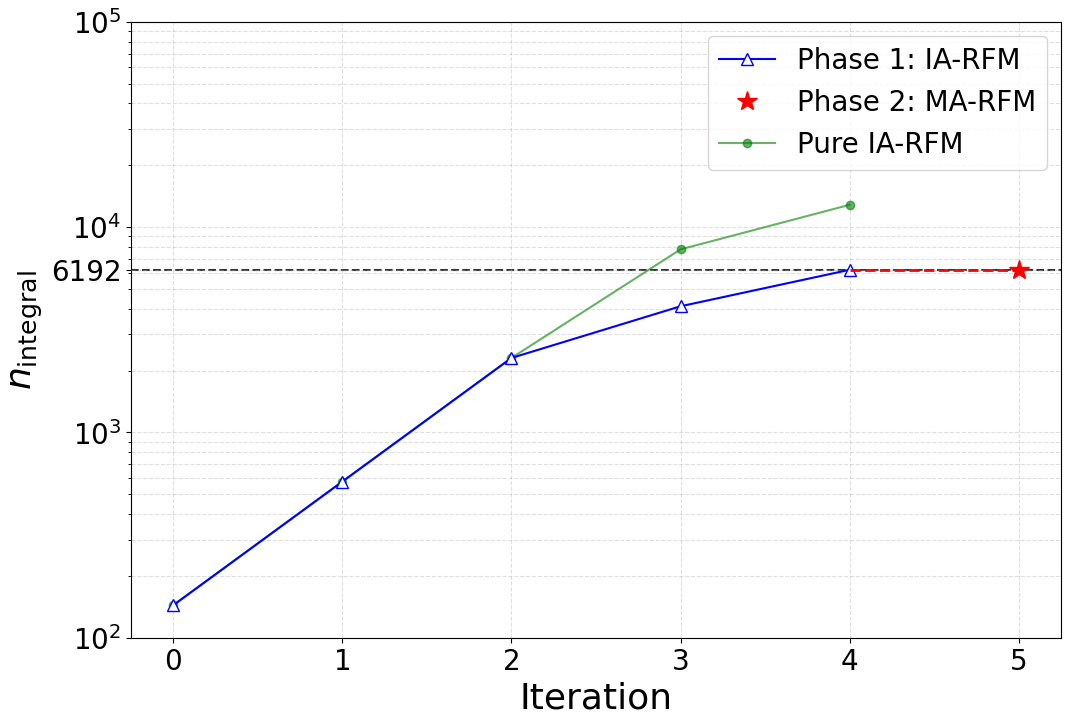

In [22]:
import numpy as np
plt.figure(figsize=(12, 8))
n1=len_cells_store1[-1]*9
n2=len_cells_store2[-1]*9
# 假设数据
iterations = range(0, len(S_MARFM))

# 1. 画 Phase 1 (IA-RFM) 部分：除了最后一个点之外的所有点
plt.plot(
    iterations[:-1], 
    [len_cells_store1[i]*9 for i in range(len(len_cells_store1)) ], 
    '-^', 
    color='blue',
    label=r'Phase 1: IA-RFM',
    markeredgecolor='blue',
    markerfacecolor='white',
    markersize=8,
    zorder=3
)

# 2. 画 Phase 2 (Transition) 部分：连接倒数第二个点和最后一个点
# 用红色虚线表示“算法切换”
plt.plot(
    iterations[-2:], 
    [len_cells_store1[-1]*9, len_cells_store1[-1]*9],
    '--', 
    color='red', 
    linewidth=2,
    zorder=3
)

# 3. 画 Phase 2 (MA-RFM) 终点：用醒目的实心点或五角星
plt.plot(
    iterations[-1], 
    len_cells_store1[-1]*9, 
    '*', 
    color='red', 
    label=r'Phase 2: MA-RFM',
    markersize=15,
    zorder=3
)

# 4. 画对比组 (IA-RFM Low Noise)
plt.plot(
    range(0, len(S_l22)),
    [len_cells_store2[i]*9 for i in range(len(len_cells_store2)) ],
    '-o',
    color='green',
    label=r'Pure IA-RFM',
    markersize=6,
    alpha=0.6,
    zorder=2
)

plt.yscale('log')
ax = plt.gca()
y_phase2 = len_cells_store1[-1]*9

# 水平虚线
ax.axhline(
    y=y_phase2,
    linestyle='--',
    color='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=1
)

# 加入 y 轴刻度
yticks = list(ax.get_yticks())
if y_phase2 not in yticks:
    yticks.append(y_phase2)
    yticks = sorted(yticks)

ax.set_yticks(yticks)

# 手动生成标签
yticklabels = []
for y in yticks:
    if abs(y - y_phase2) / y_phase2 < 1e-6:
        # Phase2 特殊值，保留科学计数
        yticklabels.append(f"{n1}")
        #yticklabels.append(f"({n2})")
    else:
        # 对数轴整十刻度显示为 10^n
        exponent = int(np.log10(y))
        yticklabels.append(r"$10^{{{}}}$".format(exponent))

ax.set_yticklabels(yticklabels)

ax.set_yticks(yticks)
ax.set_ylim(bottom=1e2,top=1e5)

plt.xlabel('Iteration', fontsize=26)
plt.ylabel(r'$n_{\text{integral}}$', fontsize=26)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', which='both', labelsize=20)
plt.legend(fontsize=20)
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.savefig('iter-intergral.pdf',bbox_inches='tight')
plt.show()